# HySwash: bathymetric profiles for SWASH

This notebook generate and visualize profiles, then select one to save as **`templates/depth.bot`**. No external data, project objects, or SWASH execution are required.

## Setup and conventions

- Distances, elevations, and depths are in meters.
- `depth > 0`: submerged bed; `depth = 0`: reference level; `depth < 0`: exposed ground.
- Plots show relative bed elevation: `z = -depth`.
- `x` increases from offshore toward land.
- `dx` is the horizontal node spacing. We use **1 m** because parabolic and biparabolic internally resample at 1 m.
- Slopes are positive and dimensionless (m/m): 0.05 means 5%, or 1 m of vertical change per 20 horizontal meters.


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
from utils.profiles import *
from utils.plotting import plot_depthfile

templates_dir = cwd / "templates"
dx = 1.0  # m
examples = {}
print(f"Output directory: {templates_dir}")


Output directory: /Users/ricondal/Documents/Github/BlueMath_Course_Corvallis/methods/hybrid_downscaling/metamodel/hyswash/templates


## 1. Reef profile: reef

A horizontal offshore section, an outer slope, a reef flat, and an inner beach.

| Variable | Meaning |
| --- | --- |
| dx | Node spacing (m) |
| h0 | Offshore depth (m) |
| Slope1 | Outer slope (m/m) |
| Slope2 | Inner beach slope (m/m) |
| Wreef | Reef flat width (m) |
| Wfore | Horizontal length before the slope toe (m) |
| bCrest | Vertical rise of the beach above the reef flat (m) |
| emsl | Reef flat depth in this implementation (m) |

Although the docstring describes emsl as mean sea level, this function assigns it directly to the reef flat depth. The crest approaches `depth = emsl - bCrest`. An additional 150 nodes dissipate overtopping flow, with depth increasing by 0.005 m per node. Endpoints are approximate: some lengths are truncated, and `np.arange` excludes the right endpoint.


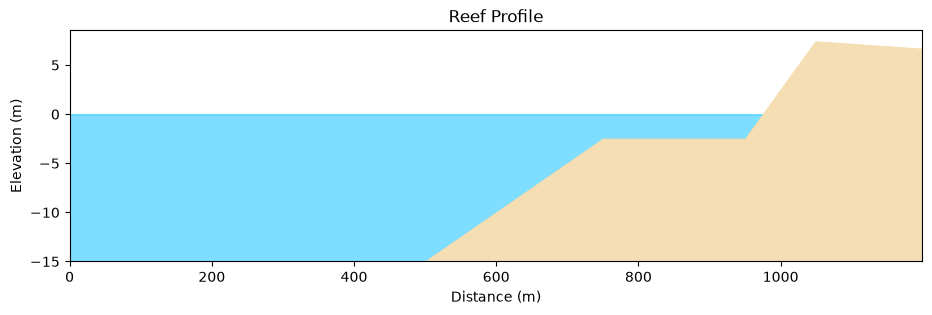

In [4]:
reef_parameters = dict(
    dx=dx, h0=15.0, Slope1=0.05, Slope2=0.10,
    Wreef=200.0, Wfore=500.0, bCrest=10.0, emsl=2.5,
)
depth_reef = reef(**reef_parameters)
examples["reef"] = (depth_reef, dx)
plot_depthfile(depth_reef)
plt.title('Reef Profile')
plt.show()


## 2. Linear beach: linear

A horizontal section followed by a beach with constant slope, extending above the zero reference level.

| Variable | Meaning |
| --- | --- |
| dx | Node spacing (m) |
| h0 | Offshore depth (m) |
| bCrest | Target crest height above the zero reference level (m) |
| m | Beach slope (m/m) |
| Wfore | Initial horizontal section length (m) |

Slope lengths are truncated to whole meters. The function adds a section behind the crest with as many nodes as the exposed beach, increasing depth by 0.005 m per node. Changing dx also changes the physical slope of this section.


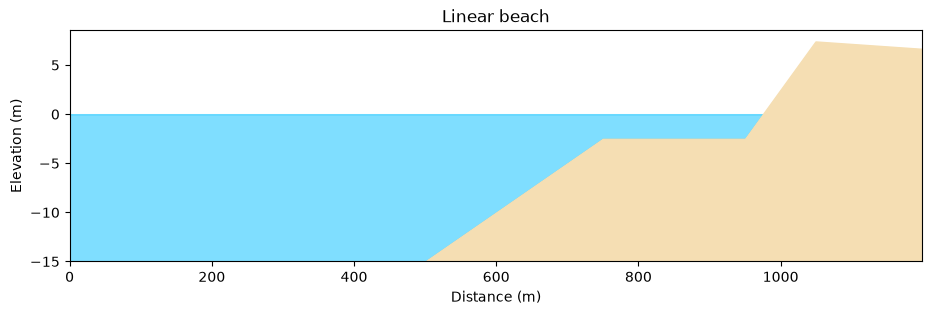

In [5]:
linear_parameters = dict(dx=dx, h0=15.0, bCrest=5.0, m=0.05, Wfore=200.0)
depth_linear = linear(**linear_parameters)
examples["linear"] = (depth_linear, dx)
plot_depthfile(depth_reef)
plt.title("Linear beach")
plt.show()


## 3. Parabolic beach: parabolic

The submerged section follows `h = A * x**(2/3)`, initially measuring x from the shoreline. The function reverses the vector to place offshore on the left and adds a linear exposed beach.

| Variable | Meaning |
| --- | --- |
| dx | Initial construction step (m); keep at 1 m |
| h0 | Target offshore depth (m) |
| A | Shape coefficient in m^(1/3); a larger A shortens the profile for the same h0 |
| xBeach | Length used to construct the exposed beach (m) |
| bCrest | Target height of the exposed beach (m) |

**Implementation detail:** the submerged section is resampled at 1 m, while the beach uses dx. Other dx values can produce inconsistent spacing or interpolation errors. The initial depth may slightly exceed h0, and the beach excludes its final endpoint.


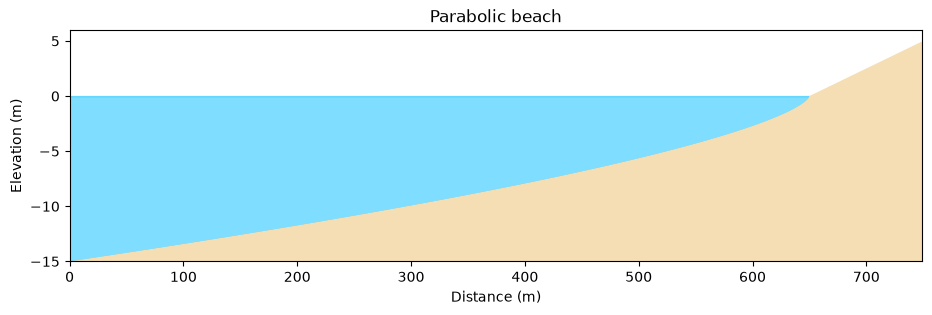

In [ ]:
parabolic_parameters = dict(dx=dx, h0=15.0, A=0.20, xBeach=100.0, bCrest=5.0)
depth_parabolic = parabolic(**parabolic_parameters)
examples["parabolic"] = (depth_parabolic, 1.0)
plot_depthfile(depth_parabolic)
plt.title("Parabolic beach")
plt.show()


## 4. Biparabolic beach: biparabolic

Combines two empirical expressions, with a transition at `hr = 1.1 * hsig + TR`.

| Variable | Meaning |
| --- | --- |
| h0 | Maximum construction depth before the tidal adjustment (m) |
| hsig | Significant wave height (m) |
| omega_surf_list | Dimensionless fall velocity parameter, between 1 and 5; pass a **scalar**, despite its name |
| TR | Tidal range: difference between high and low tide (m) |

This function does not accept dx: it returns a profile at **1 m** spacing. It subtracts TR/2 from the depths; the offshore endpoint approaches h0 - TR/2, and the landward endpoint reaches -TR/2.

**Implementation limitation:** it uses 150 vertical levels and must find one whose depth exceeds hr by less than 0.1 m. The condition `0 < hr < h0` must hold, and some parameter combinations may fail when locating the transition. The values in this demo meet these conditions.


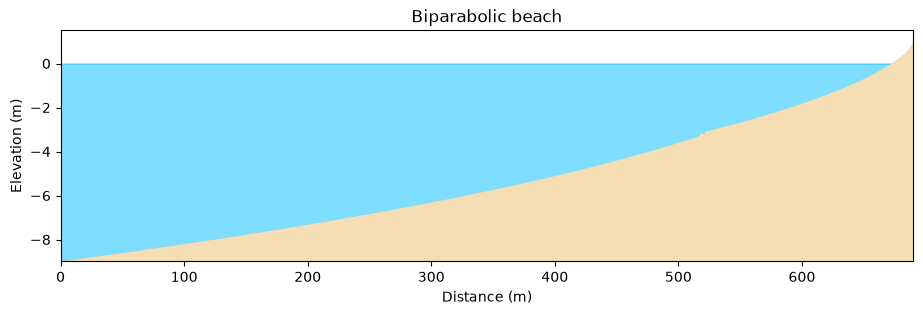

In [7]:
biparabolic_parameters = dict(h0=10.0, hsig=2.0, omega_surf_list=3.0, TR=2.0)
depth_biparabolic = biparabolic(**biparabolic_parameters)
examples["biparabolic"] = (depth_biparabolic, 1.0)
plot_depthfile(depth_biparabolic)
plt.title("Biparabolic beach")
plt.show()


## 5. Profile from points: custom_profile

Linearly interpolates points defined by the user.

| Variable | Meaning |
| --- | --- |
| dx | Positive horizontal spacing (m) |
| emsl | Water elevation relative to the points' vertical datum (m) |
| xs | Strictly increasing horizontal coordinates (m) |
| ys | Bed elevations, positive upward, relative to the same datum (m) |

xs and ys must have equal lengths and at least two points. The conversion is **depth = emsl - interpolated elevation**: a bed at -8 m and water at +1 m give a depth of 9 m. The last point is used for interpolation but is excluded from the output. Plot elevations are also expressed relative to the water level.


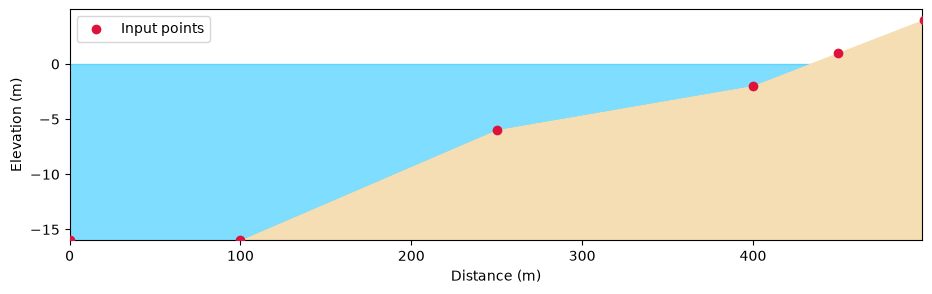

In [ ]:
xs = np.array([0, 100, 250, 400, 450, 500], dtype=float)
ys = np.array([-15, -15, -5, -1, 2, 5], dtype=float)
emsl_custom = 1.0
depth_custom = custom_profile(dx=dx, emsl=emsl_custom, xs=xs, ys=ys)
examples["custom"] = (depth_custom, dx)
ax = plot_depthfile(depth_custom)
ax.scatter(xs - xs[0], ys - emsl_custom, color="crimson", label="Input points", zorder=3)
ax.legend()
plt.show()


## Select and export to templates/depth.bot

Choose `"reef"`, `"linear"`, `"parabolic"`, `"biparabolic"`, or `"custom"`. If you change parameters, rerun the cell that generates that profile.

The next cell **overwrites templates/depth.bot** with the selected profile: plain text without a header, one depth in meters per line. It does not include x.

The `templates/INPUT.txt` template reads this file with `READINP BOTTOM 1 'depth.bot' 1 0 FREE`. Its `INPGRID BOTTOM` grid must use **mxinp = N - 1** intervals and **dxinp = dx**. The computational domain must be compatible with the bathymetry length. The required values are displayed here; INPUT.txt is not modified.


Exported profile: reef
File: /Users/ricondal/Documents/Github/BlueMath_Course_Corvallis/methods/hybrid_downscaling/metamodel/hyswash/templates/depth.bot
Nodes: 1200; mxinp: 1199; dxinp: 1 m
Bathymetry length: 1199 m


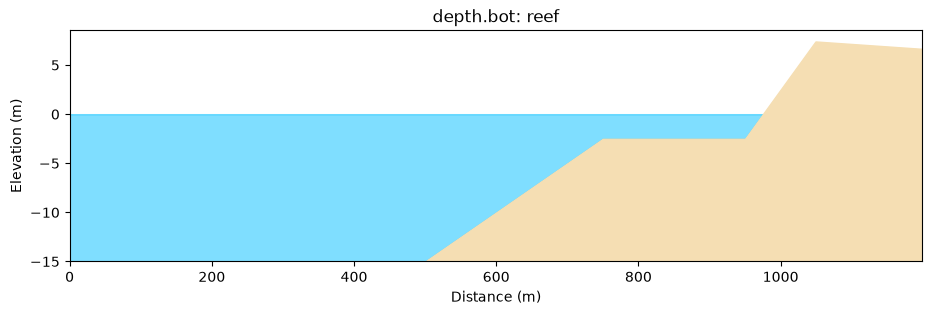

In [13]:
selected_profile = "reef"

if selected_profile not in examples:
    raise ValueError(f"Select one of these profiles: {list(examples)}")
depth, dxinp = examples[selected_profile]
depth = np.asarray(depth, dtype=float)
if depth.ndim != 1 or depth.size < 2 or not np.isfinite(depth).all():
    raise ValueError("The bathymetry must contain at least two finite depth values.")
if dxinp <= 0:
    raise ValueError("Spacing must be positive.")

templates_dir.mkdir(parents=True, exist_ok=True)
output_path = templates_dir / "depth.bot"
np.savetxt(output_path, depth, fmt="%.6f")
saved_depth = np.loadtxt(output_path)
np.testing.assert_allclose(saved_depth, depth, rtol=0, atol=5.1e-7)
mxinp = depth.size - 1
print(f"Exported profile: {selected_profile}")
print(f"File: {output_path}")
print(f"Nodes: {depth.size}; mxinp: {mxinp}; dxinp: {dxinp:g} m")
print(f"Bathymetry length: {mxinp * dxinp:g} m")
plot_depthfile(saved_depth, dxinp=dxinp)
plt.title(f"depth.bot: {selected_profile}")
plt.show()
